# From Earth to Plate - 03: The model - clustering foods by supply-chain stage profile

**Maurice Baz & Dominika Bondyra** - JH Data Patterns and Representations, final project.

This notebook is the modeling climax of the deck: an unsupervised look at 43 food products
described by the 7 supply-chain stages of their greenhouse-gas footprint. We ask whether the
foods sort themselves into meaningful families (they do - animal products self-separate), and
then use the stage profiles to make the single most actionable point of the project:
for the highest-impact foods, almost all damage happens on the farm and in land-use change,
not in transport.

**Deck mapping:** slide 6 (supply-chain clustering) + the slide-12 methods appendix
(model-selection metrics and sensitivity checks).


## Data and basis decision

- **Source:** Poore & Nemecek (2018), *Reducing food's environmental impacts through producers
  and consumers*, Science - global average emissions for 43 food products, as distributed by
  Our World in Data (`data/Food_Product_Emissions.csv`). Units: **kg CO2e per kg of food**.
- **Features:** the 7 stage columns - Land Use Change, Feed, Farm, Processing, Transport,
  Packaging, Retail. They sum (within rounding) to the **"Total from Land to Retail"** column,
  which we call the *land-to-retail total* and use as the emissions basis everywhere in this
  project. Rationale: it is a consistent supply-chain accounting boundary for every food.
  (The alternative "Total Global Average" column adds post-retail losses and consumer waste;
  on that basis beef reads 99.5 kg CO2e per kg instead of 59.6 - we footnote it where relevant
  but never mix the two bases.)
- **Negative values:** Land Use Change is *negative* for some crops (Nuts -2.05, Olive Oil
  -0.38, small negatives for Apples, Bananas, Citrus, Potatoes, Rice, Wine). Negative means
  net carbon **sequestration** - e.g. nut orchards standing on former cropland. We keep the
  sign: it is real signal, and we handle it explicitly in the composition chart.
- **Category labels** (used across all four notebooks): 10 **animal-based** products -
  Beef (beef herd), Beef (dairy herd), Cheese, Eggs, Fish (farmed), Lamb & Mutton, Milk,
  Pig Meat, Poultry Meat, Shrimps (farmed) - and 33 **plant-based**. The categories are
  *held out* of the model and used only to validate the clusters afterwards.


In [1]:
# Setup: libraries, robust paths, and the shared house style
import os
os.environ.setdefault('OMP_NUM_THREADS', '4')  # silences the Windows/MKL KMeans warning

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA, FIGS = ROOT / 'data', ROOT / 'figures'
FIGS.mkdir(exist_ok=True)

# --- house style (identical across the four project notebooks) ---
SURFACE = '#fcfcfb'
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, BASE = '#e1e0d9', '#c3c2b7'
SLOTS = ['#2a78d6', '#008300', '#e87ba4', '#eda100', '#1baf7a', '#eb6834', '#4a3aa7']
BLUE, GREEN, MAGENTA, YELLOW, AQUA, ORANGE, VIOLET = SLOTS
LIGHT_BLUE, EMPH_BLUE = '#9ec5f4', '#104281'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans'],
    'text.color': INK, 'axes.titlecolor': INK,
    'axes.labelcolor': MUTED, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': BASE, 'axes.linewidth': 1.0,
    'grid.color': GRID, 'grid.linewidth': 0.8, 'grid.linestyle': '-',
    'legend.frameon': False,
})

def style_ax(ax, value_axis='y', spines=('bottom',)):
    """Hairline grid on the value axis only, behind the data; no chart box."""
    ax.set_axisbelow(True)
    for a in ('x', 'y'):
        if value_axis in (a, 'both'):
            ax.grid(True, axis=a, color=GRID, linewidth=0.8)
        else:
            ax.grid(False, axis=a)
    for side in ('top', 'right', 'left', 'bottom'):
        ax.spines[side].set_visible(side in spines)
        if side in spines:
            ax.spines[side].set_color(BASE)

def title_block(ax, title, subtitle, pad=32, sub_y=1.02):
    ax.set_title(title, loc='left', fontsize=13, fontweight=600, color=INK, pad=pad)
    ax.text(0, sub_y, subtitle, transform=ax.transAxes, fontsize=9.5, color=INK2, va='bottom')

def source_note(fig, text='Source: Poore & Nemecek (2018), via Our World in Data', y=-0.02):
    fig.text(0.01, y, text, fontsize=8.5, color=MUTED, ha='left')

def ink_on(hexcolor):
    """Label ink inside a colored fill: white or near-black, chosen by fill luminance."""
    r, g, b = (int(hexcolor[i:i + 2], 16) / 255 for i in (1, 3, 5))
    lin = [c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4 for c in (r, g, b)]
    lum = 0.2126 * lin[0] + 0.7152 * lin[1] + 0.0722 * lin[2]
    return INK if lum > 0.3 else '#ffffff'

def save_fig(fig, name):
    path = FIGS / name
    fig.savefig(path, dpi=200, bbox_inches='tight', facecolor=SURFACE)
    print('saved', path)


In [2]:
df = pd.read_csv(DATA / 'Food_Product_Emissions.csv')
STAGES = ['Land Use Change', 'Feed', 'Farm', 'Processing', 'Transport', 'Packaging', 'Retail']
TOTAL = 'Total from Land to Retail'
ANIMAL = ['Beef (beef herd)', 'Beef (dairy herd)', 'Cheese', 'Eggs', 'Fish (farmed)',
          'Lamb & Mutton', 'Milk', 'Pig Meat', 'Poultry Meat', 'Shrimps (farmed)']
df['Category'] = np.where(df['Food product'].isin(ANIMAL), 'Animal-based', 'Plant-based')

# Sanity checks: 43 foods, no missing values, stages reconcile to the land-to-retail total
assert len(df) == 43 and df[STAGES + [TOTAL]].notna().all().all()
assert np.allclose(df[STAGES].sum(axis=1), df[TOTAL], atol=0.02), 'stages must sum to the total'
assert (df['Category'] == 'Animal-based').sum() == 10

ix = df.set_index('Food product')
ratio = ix.loc['Beef (beef herd)', TOTAL] / ix.loc['Peas', TOTAL]
print(f"{len(df)} foods | {df['Category'].value_counts().to_dict()}")
print(f"Land-to-retail totals: Beef (beef herd) {ix.loc['Beef (beef herd)', TOTAL]:.2f}, "
      f"Peas {ix.loc['Peas', TOTAL]:.3f} kg CO2e/kg -> ratio {ratio:.1f}x")
df.head(6)


43 foods | {'Plant-based': 33, 'Animal-based': 10}
Land-to-retail totals: Beef (beef herd) 59.57, Peas 0.896 kg CO2e/kg -> ratio 66.5x


,Food product,Land Use Change,Feed,Farm,Processing,Transport,Packaging,Retail,Total from Land to Retail,Total Global Average GHG Emissions per kg,Unit of GHG Emissions,Category
0,Apples,-0.029,0.000,0.225,0.004,0.096,0.044,0.017,0.357,0.43,kg CO2e per kg food produced,Plant-based
1,Bananas,-0.025,0.000,0.266,0.059,0.292,0.065,0.021,0.678,0.86,kg CO2e per kg food produced,Plant-based
2,Barley,0.009,0.000,0.176,0.128,0.035,0.497,0.264,1.109,1.18,kg CO2e per kg food produced,Plant-based
3,Beef (beef herd),16.278,1.878,39.388,1.269,0.346,0.247,0.164,59.570,99.48,kg CO2e per kg food produced,Animal-based
4,Beef (dairy herd),0.906,2.508,15.689,1.108,0.424,0.268,0.182,21.085,33.30,kg CO2e per kg food produced,Animal-based
5,Beet Sugar,0.000,0.000,0.536,0.242,0.629,0.090,0.039,1.536,1.81,kg CO2e per kg food produced,Plant-based


## Method: standardize, cluster, score, validate

1. **Features = the 7 raw stage values** (kg CO2e per kg) for each food. We cluster on raw
   magnitudes - not on percentage shares - because *how much* a food emits at each stage is the
   story the deck tells; a share-based (magnitude-blind) version is run as a sensitivity check
   in the appendix.
2. **StandardScaler** on every column. K-means is a Euclidean-distance method, and the stage
   columns live on wildly different scales (Farm spans 0.09-39.4; Retail spans 0.015-0.33).
   Without standardization the Farm column alone would decide everything.
3. **KMeans** for k = 2..5, `n_init=20` restarts, `random_state=42` (reproducible).
4. **Silhouette score** for each k (higher = tighter, better-separated clusters), but the final
   k must also pass an *interpretability* test: every cluster should be nameable, and we report
   cluster sizes honestly because one food - Beef (beef herd), with Farm 39.4 and Land Use
   Change 16.3 - is extreme enough to become its own cluster at larger k.
5. **Validation:** the held-out animal/plant labels are crosstabbed against the clusters.
   PCA is used only to *draw* the 7-dimensional result in 2D, never to fit it.


In [3]:
X = StandardScaler().fit_transform(df[STAGES].to_numpy())

K_RANGE = range(2, 6)
fits, rows = {}, []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    fits[k] = km
    sizes = np.sort(np.bincount(km.labels_))[::-1]
    rows.append({'k': k,
                 'silhouette': round(silhouette_score(X, km.labels_), 3),
                 'cluster sizes (desc)': ' | '.join(map(str, sizes)),
                 'smallest cluster': int(sizes.min())})
sel = pd.DataFrame(rows).set_index('k')
sel


,silhouette,cluster sizes (desc),smallest cluster
k,,,
2,0.456,36 | 7,7
3,0.398,28 | 8 | 7,7
4,0.410,26 | 10 | 6 | 1,1
5,0.436,24 | 8 | 6 | 4 | 1,1


saved C:\Users\M\code\JH-2026-Final-Project\figures\fig_slide06_silhouette.png


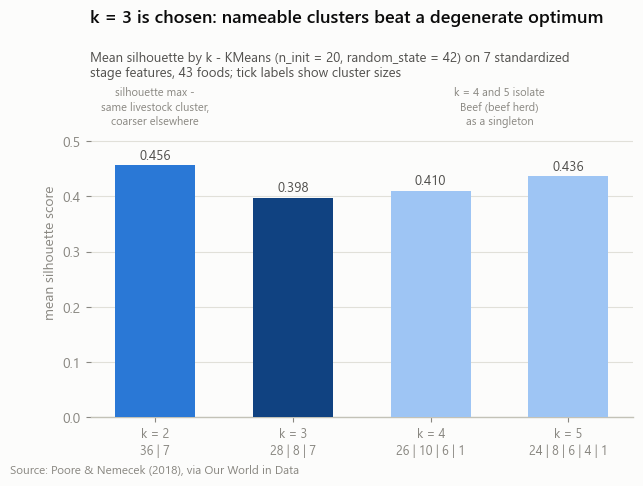

In [4]:
CHOSEN_K = 3
sil = {k: silhouette_score(X, fits[k].labels_) for k in K_RANGE}
sizes_txt = {k: ' | '.join(map(str, np.sort(np.bincount(fits[k].labels_))[::-1])) for k in K_RANGE}

fig, ax = plt.subplots(figsize=(7, 4.3))
ks = list(K_RANGE)
colors = [EMPH_BLUE if k == CHOSEN_K else (BLUE if k == 2 else LIGHT_BLUE) for k in ks]
ax.bar(ks, [sil[k] for k in ks], width=0.58, color=colors, zorder=3)
for k in ks:
    ax.text(k, sil[k] + 0.012, f'{sil[k]:.3f}', ha='center', fontsize=9.5, color=INK2)

ax.text(2, 0.60, 'silhouette max -\nsame livestock cluster,\ncoarser elsewhere',
        ha='center', va='top', fontsize=8, color=MUTED, linespacing=1.3)
ax.text(4.5, 0.60, 'k = 4 and 5 isolate\nBeef (beef herd)\nas a singleton',
        ha='center', va='top', fontsize=8, color=MUTED, linespacing=1.3)

ax.set_xticks(ks)
ax.set_xticklabels([f'k = {k}\n{sizes_txt[k]}' for k in ks], fontsize=9, linespacing=1.4)
ax.set_ylim(0, 0.60)
ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
ax.set_ylabel('mean silhouette score')
style_ax(ax, 'y', ('bottom',))
title_block(ax, 'k = 3 is chosen: nameable clusters beat a degenerate optimum',
            'Mean silhouette by k - KMeans (n_init = 20, random_state = 42) on 7 standardized\n'
            'stage features, 43 foods; tick labels show cluster sizes',
            pad=46)
source_note(fig)
save_fig(fig, 'fig_slide06_silhouette.png')
plt.show()


**Choosing k (documented for the slide-12 appendix).** The silhouette optimum is **k = 2
(0.456)**: a 7-food high-impact cluster versus the other 36. **k = 3 (0.398)** keeps that
7-food cluster *unchanged* and splits the remainder into two nameable families, so we present
k = 3. The honest wrinkle: k = 4 (0.410) and k = 5 (0.436) score *above* k = 3, but both
achieve it by isolating **Beef (beef herd) as a singleton cluster** (sizes 26 | 10 | 6 | 1 and
24 | 8 | 6 | 4 | 1) - a degenerate optimum driven by one extreme outlier (Farm 39.4, Land Use
Change 16.3 kg CO2e per kg), not a new food family. A k where every cluster is nameable beats
a k that wins its score by quarantining one row; we keep k = 3 and report both silhouettes
(0.456 coarse, 0.398 presented) in the appendix table.


In [5]:
km = fits[CHOSEN_K]
df['cluster_id'] = km.labels_
cid = df.set_index('Food product')['cluster_id']

# Name clusters via anchor foods (robust to arbitrary k-means label order)
livestock_id = int(cid['Beef (beef herd)'])
oils_id = int(cid['Palm Oil'])
staples_id = ({0, 1, 2} - {livestock_id, oils_id}).pop()
CLUSTER_NAME = {livestock_id: 'Livestock & dairy',
                staples_id: 'Low-impact staples',
                oils_id: 'Oil crops, sugar & coffee'}
CLUSTER_COLOR = {livestock_id: BLUE, staples_id: GREEN, oils_id: MAGENTA}
CLUSTER_ORDER = [livestock_id, staples_id, oils_id]
df['Cluster'] = df['cluster_id'].map(CLUSTER_NAME)

print('Cluster sizes:', df['Cluster'].value_counts().to_dict(), '\n')
crosstab = pd.crosstab(df['Cluster'], df['Category'])
print(crosstab, '\n')
for i in (livestock_id, oils_id):
    members = sorted(df.loc[df['cluster_id'] == i, 'Food product'])
    print(f'{CLUSTER_NAME[i]} (n={len(members)}): {members}')
print('\nAnimal-based foods NOT in the livestock cluster:',
      sorted(df.loc[(df['Category'] == 'Animal-based') & (df['cluster_id'] != livestock_id),
                    'Food product']))
print('\nMean land-to-retail total by cluster (kg CO2e/kg):')
print(df.groupby('Cluster')[TOTAL].agg(['mean', 'median']).round(2))


Cluster sizes: {'Low-impact staples': 28, 'Oil crops, sugar & coffee': 8, 'Livestock & dairy': 7} 

Category                   Animal-based  Plant-based
Cluster                                             
Livestock & dairy                     7            0
Low-impact staples                    3           25
Oil crops, sugar & coffee             0            8 

Livestock & dairy (n=7): ['Beef (beef herd)', 'Beef (dairy herd)', 'Cheese', 'Lamb & Mutton', 'Pig Meat', 'Poultry Meat', 'Shrimps (farmed)']
Oil crops, sugar & coffee (n=8): ['Beet Sugar', 'Cane Sugar', 'Coffee', 'Olive Oil', 'Palm Oil', 'Rapeseed Oil', 'Soybean Oil', 'Sunflower Oil']

Animal-based foods NOT in the livestock cluster: ['Eggs', 'Fish (farmed)', 'Milk']

Mean land-to-retail total by cluster (kg CO2e/kg):
                            mean  median
Cluster                                 
Livestock & dairy          21.65   21.08
Low-impact staples          2.09    1.05
Oil crops, sugar & coffee   5.97    4.89


**Validation: the clusters recover animal vs plant without ever seeing the labels.**

| Cluster (k = 3) | Animal-based | Plant-based | Mean total (kg CO2e/kg) |
|---|---:|---:|---:|
| Livestock & dairy | **7** | **0** | 21.6 |
| Low-impact staples | 3 | 25 | 2.1 |
| Oil crops, sugar & coffee | 0 | 8 | 6.0 |

- The **Livestock & dairy** cluster (both beef herds, Lamb & Mutton, Cheese, Pig Meat, Poultry
  Meat, Shrimps) is 100% animal-based. The three animal foods it *excludes* - Eggs (4.5),
  Fish (5.2), Milk (2.8 kg CO2e/kg) - are exactly the low-impact animal products; they sit
  with the plant staples, which is the model agreeing with the deck's ranking story.
- The third cluster is a genuine discovery: **Beet Sugar, Cane Sugar, Coffee, Olive/Palm/
  Rapeseed/Soybean/Sunflower Oil** - processed oil and tropical commodity crops whose
  emissions concentrate in land-use change, processing and packaging. **Coffee** (16.5 kg
  CO2e/kg, animal-scale) lands here at k = 3. **Dark Chocolate** (18.7 kg) stays with the
  staples at k = 3 but joins this tropical family at k = 4 and under Ward linkage (appendix) -
  the two famous plant foods with animal-scale footprints form their own land-use-change
  family rather than joining the livestock cluster.


saved C:\Users\M\code\JH-2026-Final-Project\figures\fig_slide06_clusters_pca.png


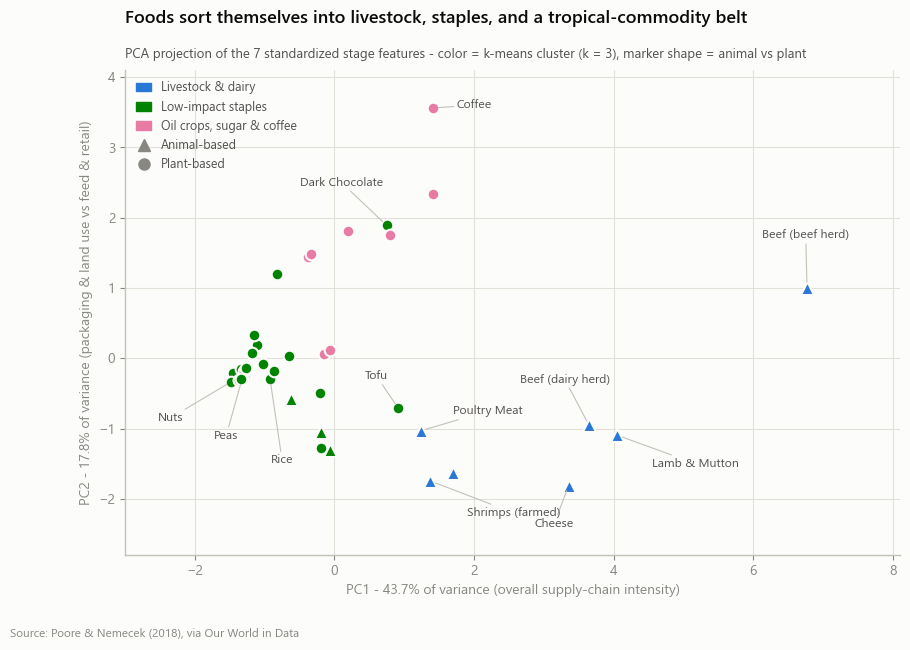

In [6]:
pca = PCA(n_components=2, random_state=42)
XY = pca.fit_transform(X)
evr = pca.explained_variance_ratio_ * 100
pts = pd.DataFrame({'x': XY[:, 0], 'y': XY[:, 1], 'food': df['Food product'],
                    'cluster_id': df['cluster_id'],
                    'animal': (df['Category'] == 'Animal-based')})

fig, ax = plt.subplots(figsize=(10, 6.3))
for i in CLUSTER_ORDER:
    for is_animal, mk, sz in [(True, '^', 88), (False, 'o', 70)]:
        s = pts[(pts.cluster_id == i) & (pts.animal == is_animal)]
        if len(s):
            ax.scatter(s.x, s.y, s=sz, marker=mk, color=CLUSTER_COLOR[i],
                       edgecolor=SURFACE, linewidth=1.5, zorder=3)

ANNOTS = {  # food: (text x, text y, ha)
    'Beef (beef herd)':  (6.75, 1.75, 'center'),
    'Beef (dairy herd)': (3.30, -0.30, 'center'),
    'Lamb & Mutton':     (4.55, -1.50, 'left'),
    'Cheese':            (3.15, -2.35, 'center'),
    'Shrimps (farmed)':  (1.90, -2.20, 'left'),
    'Poultry Meat':      (1.70, -0.75, 'left'),
    'Tofu':              (0.60, -0.25, 'center'),
    'Dark Chocolate':    (0.10, 2.50, 'center'),
    'Coffee':            (1.75, 3.60, 'left'),
    'Rice':              (-0.75, -1.45, 'center'),
    'Peas':              (-1.55, -1.10, 'center'),
    'Nuts':              (-2.35, -0.85, 'center'),
}
for food, (tx, ty, ha) in ANNOTS.items():
    r = pts.loc[pts.food == food].iloc[0]
    ax.annotate(food, xy=(r.x, r.y), xytext=(tx, ty), ha=ha, va='center',
                fontsize=8.8, color=INK2,
                arrowprops=dict(arrowstyle='-', color=BASE, lw=0.8, shrinkA=0, shrinkB=4))

handles = [Patch(color=CLUSTER_COLOR[i], label=CLUSTER_NAME[i]) for i in CLUSTER_ORDER]
handles += [Line2D([], [], ls='', marker='^', markersize=8, color=MUTED, label='Animal-based'),
            Line2D([], [], ls='', marker='o', markersize=8, color=MUTED, label='Plant-based')]
ax.legend(handles=handles, loc='upper left', fontsize=9, labelcolor=INK2, handlelength=1.2)

ax.set_xlim(-3.0, 8.1)
ax.set_ylim(-2.8, 4.1)
ax.set_xlabel(f'PC1 - {evr[0]:.1f}% of variance (overall supply-chain intensity)')
ax.set_ylabel(f'PC2 - {evr[1]:.1f}% of variance (packaging & land use vs feed & retail)')
style_ax(ax, 'both', ('bottom', 'left'))
title_block(ax, 'Foods sort themselves into livestock, staples, and a tropical-commodity belt',
            'PCA projection of the 7 standardized stage features - color = k-means cluster '
            '(k = 3), marker shape = animal vs plant', pad=34)
source_note(fig)
save_fig(fig, 'fig_slide06_clusters_pca.png')
plt.show()


**Reading the map.** PC1 (43.7% of variance, all seven stages loading positive) is simply
*overall supply-chain intensity*: Beef (beef herd) sits alone at the far right, about twice as
far out as anything else - the visual argument for why k = 4 and 5 wanted to quarantine it.
PC2 (17.8%; together 61.5% of variance shown) separates the packaging/land-use-heavy tropical
and oil crops (top) from the feed-and-retail-heavy animal products (bottom). Note the
triangles (animal) inside the green staples cluster - Eggs, Fish, Milk - and the two circles
drifting toward the top - Dark Chocolate and Coffee, plant foods with animal-scale totals.


## The insight: WHERE the damage happens

Clustering told us *which* foods behave alike; the composition of each food's footprint tells
us *why* - and it demolishes the most popular intuition about food emissions ("eat local").
Below, each bar is a food's stage mix as a share of its land-to-retail footprint.

*Handling negative values:* shares are computed against the **gross** total (sum of positive
stages), so the positive side of every bar sums to 100% and negative land-use change (net
sequestration) extends *left* of the baseline. For every food shown except Nuts and Rice the
gross and net totals are identical, so the shares equal shares of the land-to-retail total;
for Nuts (net total only 0.28 kg because sequestration cancels most of it) the gross basis is
what keeps the bar readable.


saved C:\Users\M\code\JH-2026-Final-Project\figures\fig_slide06_stage_stacked.png


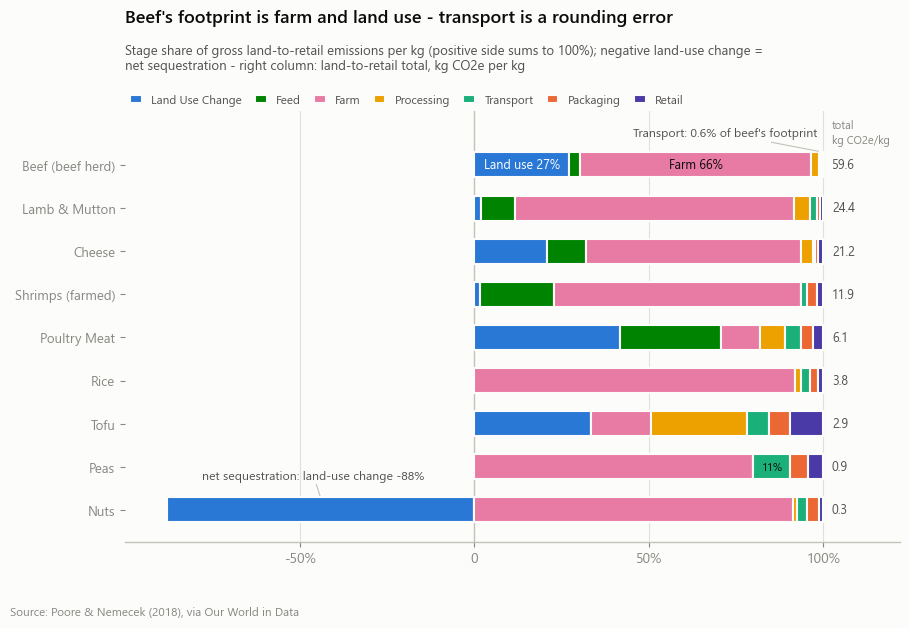

In [7]:
CURATED = ['Beef (beef herd)', 'Lamb & Mutton', 'Cheese', 'Shrimps (farmed)',
           'Poultry Meat', 'Rice', 'Tofu', 'Peas', 'Nuts']
sub = df.set_index('Food product').loc[CURATED]
gross = sub[STAGES].clip(lower=0).sum(axis=1)
shares = sub[STAGES].div(gross, axis=0) * 100  # positive side sums to 100

fig, ax = plt.subplots(figsize=(10, 5.6))
y = np.arange(len(CURATED))
pos_edge, neg_edge = np.zeros(len(y)), np.zeros(len(y))
for stage, color in zip(STAGES, SLOTS):
    vals = shares[stage].to_numpy()
    left = np.where(vals >= 0, pos_edge, neg_edge + vals)
    ax.barh(y, np.abs(vals), left=left, height=0.58, color=color,
            edgecolor=SURFACE, linewidth=1.5, zorder=3, label=stage)
    pos_edge += np.clip(vals, 0, None)
    neg_edge += np.clip(vals, None, 0)

ax.set_yticks(y)
ax.set_yticklabels(CURATED, fontsize=9.5)
ax.invert_yaxis()
ax.set_ylim(8.75, -1.25)

# Selective labels: the beef story, plus the Nuts sequestration note
b = shares.loc['Beef (beef herd)']
ax.text(b['Land Use Change'] / 2, 0, f"Land use {b['Land Use Change']:.0f}%",
        ha='center', va='center', fontsize=9, color=ink_on(BLUE), zorder=4)
ax.text(b['Land Use Change'] + b['Feed'] + b['Farm'] / 2, 0, f"Farm {b['Farm']:.0f}%",
        ha='center', va='center', fontsize=9, color=ink_on(MAGENTA), zorder=4)
beef_t = sub.loc['Beef (beef herd)', 'Transport'] / sub.loc['Beef (beef herd)', TOTAL] * 100
t_mid = b[['Land Use Change', 'Feed', 'Farm', 'Processing']].sum() + b['Transport'] / 2
ax.annotate(f"Transport: {beef_t:.1f}% of beef's footprint",
            xy=(t_mid, -0.31), xytext=(72, -0.66), ha='center', fontsize=8.8, color=INK2,
            arrowprops=dict(arrowstyle='-', color=BASE, lw=0.8, shrinkA=0, shrinkB=1))
nuts_luc = shares.loc['Nuts', 'Land Use Change']
ax.annotate(f'net sequestration: land-use change {nuts_luc:.0f}%',
            xy=(nuts_luc / 2, 7.70), xytext=(-46, 7.28), ha='center', fontsize=8.8, color=INK2,
            arrowprops=dict(arrowstyle='-', color=BASE, lw=0.8, shrinkA=0, shrinkB=1))
p = shares.loc['Peas']
peas_t_mid = p[['Land Use Change', 'Feed', 'Farm', 'Processing']].sum() + p['Transport'] / 2
ax.text(peas_t_mid, 7, f"{p['Transport']:.0f}%", ha='center', va='center',
        fontsize=8, color=ink_on(AQUA), zorder=4)

# Right column: the absolute totals (the 10-60x lever)
for yi, food in enumerate(CURATED):
    ax.text(102.5, yi, f'{sub.loc[food, TOTAL]:.1f}', va='center', ha='left',
            fontsize=9, color=INK2)
ax.text(102.5, -0.75, 'total\nkg CO2e/kg', ha='left', va='center', fontsize=8,
        color=MUTED, linespacing=1.3)

ax.axvline(0, color=BASE, lw=1.0, zorder=2)
ax.set_xlim(-100, 122)
ax.set_xticks([-50, 0, 50, 100])
ax.set_xticklabels(['-50%', '0', '50%', '100%'])
style_ax(ax, 'x', ('bottom',))
ax.legend(loc='lower left', bbox_to_anchor=(0, 1.0), ncol=7, fontsize=8.5,
          handlelength=1.0, columnspacing=1.1, labelcolor=INK2, borderaxespad=0)
title_block(ax, "Beef's footprint is farm and land use - transport is a rounding error",
            'Stage share of gross land-to-retail emissions per kg (positive side sums to 100%); '
            'negative land-use change =\nnet sequestration - right column: land-to-retail total, '
            'kg CO2e per kg', pad=64, sub_y=1.09)
source_note(fig)
save_fig(fig, 'fig_slide06_stage_stacked.png')
plt.show()


In [8]:
# Numbers for the deck (computed, not typed)
beef_r = ix.loc['Beef (beef herd)']
print(f"Beef transport share: {beef_r['Transport']:.3f} / {beef_r[TOTAL]:.2f} = "
      f"{beef_r['Transport'] / beef_r[TOTAL] * 100:.2f}%")
print(f"Beef farm + land-use change share: "
      f"{(beef_r['Farm'] + beef_r['Land Use Change']) / beef_r[TOTAL] * 100:.1f}%")
print(f"Beef vs peas, land-to-retail: {beef_r[TOTAL] / ix.loc['Peas', TOTAL]:.1f}x")
print(f"Beef vs peas, total-global-average basis (incl. post-retail): "
      f"{beef_r['Total Global Average GHG Emissions per kg'] / ix.loc['Peas', 'Total Global Average GHG Emissions per kg']:.0f}x")
tshare = (df['Transport'] / df[TOTAL] * 100)
print(f"Max transport share among foods with totals > 5 kg CO2e/kg: "
      f"{tshare[df[TOTAL] > 5].max():.1f}% ({df.loc[tshare[df[TOTAL] > 5].idxmax(), 'Food product']})")
big_t = df.loc[tshare > 25, ['Food product', TOTAL]].assign(share=tshare[tshare > 25].round(0))
print('\nFoods where transport exceeds 25% of the footprint (all low-impact):')
print(big_t.sort_values('share', ascending=False).to_string(index=False))


Beef transport share: 0.346 / 59.57 = 0.58%
Beef farm + land-use change share: 93.4%
Beef vs peas, land-to-retail: 66.5x
Beef vs peas, total-global-average basis (incl. post-retail): 102x
Max transport share among foods with totals > 5 kg CO2e/kg: 8.1% (Olive Oil)

Foods where transport exceeds 25% of the footprint (all low-impact):
    Food product  Total from Land to Retail  share
         Bananas                      0.678   43.0
      Beet Sugar                      1.536   41.0
Other Vegetables                      0.455   36.0
 Root Vegetables                      0.365   31.0
    Citrus Fruit                      0.317   30.0
      Cane Sugar                      2.672   29.0
          Apples                      0.357   27.0
        Potatoes                      0.370   25.0


**Takeaway - the slide-6 punchline.** For Beef (beef herd), transport is **0.346 of 59.57 kg
CO2e/kg = 0.6%** of the footprint, and farm + land-use change together are **93.4%**
(66% on-farm - mostly cattle methane - plus 27% land-use change). The pattern holds across the
livestock cluster: transport never exceeds ~5% of any animal product's footprint, and among
*all* foods above 5 kg CO2e/kg the largest transport share is 8.1% (Olive Oil). Transport only
becomes a big *share* (25-43%) for foods whose totals are already tiny - Bananas (43% of
0.68 kg), Beet Sugar (41% of 1.5 kg), Apples (27% of 0.36 kg).

**"Eat local" therefore optimizes one of the smallest slices of the highest-impact foods,
while switching *what* you eat moves the whole bar: beef to peas is 59.6 vs 0.9 kg CO2e/kg -
a 66x difference on the land-to-retail basis** (about 100x on the "Total Global Average"
basis that includes post-retail losses: 99.5 vs 1.0). Rice and Tofu - the plant swaps on the
chart - sit at 3.8 and 2.9 kg, an order of magnitude below the ruminants, and Nuts even end
up *net-negative* on land use because orchards sequester carbon.


## Appendix (slide 12): sensitivity and robustness checks

**Check 1 - magnitude-blind clustering.** Re-run the identical pipeline on stage
**composition shares** (each stage divided by the food's land-to-retail total) instead of raw
values. This deliberately erases *how much* each food emits and keeps only *where along the
chain* it emits - if our headline separation were an artifact of preprocessing, it would
survive this change. One caveat to expect: Nuts' near-zero net total (0.28 kg) makes its
shares explode (land-use change -738%, farm +765%), so the shares view is predisposed to
treat Nuts as an outlier.

**Check 2 - a different algorithm family.** Ward hierarchical clustering (scipy) on the same
standardized raw features, cut at 3 clusters, to confirm the grouping is not a k-means
artifact.


   silhouette cluster sizes (desc)
k                                 
2       0.689               42 | 1
3       0.264          26 | 16 | 1
4       0.275      27 | 12 | 3 | 1
5       0.299  22 | 12 | 5 | 3 | 1 

Category                       Animal-based  Plant-based
shares cluster                                          
Downstream-heavy                          0           16
Farm/land-use dominated                  10           16
Nuts (sequestration artifact)             0            1 

Farm/land-use dominated contains, e.g.: ['Beef (beef herd)', 'Coffee', 'Dark Chocolate', 'Oatmeal', 'Peas', 'Rice']


saved C:\Users\M\code\JH-2026-Final-Project\figures\fig_slide06_composition_check.png


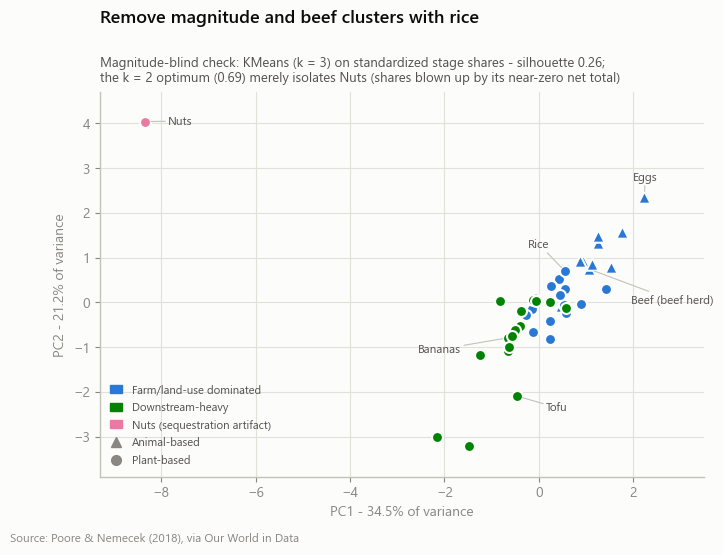

In [9]:
shares_all = df[STAGES].div(df[TOTAL], axis=0)
Xs = StandardScaler().fit_transform(shares_all.to_numpy())

fits_s, rows_s = {}, []
for k in K_RANGE:
    km_s = KMeans(n_clusters=k, n_init=20, random_state=42).fit(Xs)
    fits_s[k] = km_s
    rows_s.append({'k': k,
                   'silhouette': round(silhouette_score(Xs, km_s.labels_), 3),
                   'cluster sizes (desc)': ' | '.join(
                       map(str, np.sort(np.bincount(km_s.labels_))[::-1]))})
sel_s = pd.DataFrame(rows_s).set_index('k')
print(sel_s, '\n')

lab_s = fits_s[3].labels_
cid_s = pd.Series(lab_s, index=df['Food product'])
farm_id = int(cid_s['Beef (beef herd)'])
down_id = int(cid_s['Bananas'])
nuts_id = int(cid_s['Nuts'])
NAME_S = {farm_id: 'Farm/land-use dominated', down_id: 'Downstream-heavy',
          nuts_id: 'Nuts (sequestration artifact)'}
COLOR_S = {farm_id: BLUE, down_id: GREEN, nuts_id: MAGENTA}
print(pd.crosstab(pd.Series(lab_s).map(NAME_S).rename('shares cluster'), df['Category']), '\n')
print('Farm/land-use dominated contains, e.g.:',
      sorted(set(df.loc[lab_s == farm_id, 'Food product'])
             & {'Beef (beef herd)', 'Rice', 'Coffee', 'Dark Chocolate', 'Peas', 'Oatmeal'}))

pca_s = PCA(n_components=2, random_state=42)
XYs = pca_s.fit_transform(Xs)
evr_s = pca_s.explained_variance_ratio_ * 100
pts_s = pd.DataFrame({'x': XYs[:, 0], 'y': XYs[:, 1], 'food': df['Food product'],
                      'c': lab_s, 'animal': (df['Category'] == 'Animal-based')})

fig, ax = plt.subplots(figsize=(7.8, 5.0))
for i in (farm_id, down_id, nuts_id):
    for is_animal, mk, sz in [(True, '^', 80), (False, 'o', 62)]:
        s = pts_s[(pts_s.c == i) & (pts_s.animal == is_animal)]
        if len(s):
            ax.scatter(s.x, s.y, s=sz, marker=mk, color=COLOR_S[i],
                       edgecolor=SURFACE, linewidth=1.5, zorder=3)
ANNOTS_S = {'Beef (beef herd)': (1.95, 0.05, 'left'), 'Rice': (0.0, 1.3, 'center'),
            'Eggs': (2.25, 2.80, 'center'), 'Bananas': (-2.1, -1.05, 'center'),
            'Tofu': (0.15, -2.35, 'left'), 'Nuts': (-7.85, 4.05, 'left')}
for food, (tx, ty, ha) in ANNOTS_S.items():
    r = pts_s.loc[pts_s.food == food].iloc[0]
    ax.annotate(food, xy=(r.x, r.y), xytext=(tx, ty), ha=ha, va='center',
                fontsize=8.5, color=INK2,
                arrowprops=dict(arrowstyle='-', color=BASE, lw=0.8, shrinkA=0, shrinkB=4))
handles = [Patch(color=COLOR_S[i], label=NAME_S[i]) for i in (farm_id, down_id, nuts_id)]
handles += [Line2D([], [], ls='', marker='^', markersize=7, color=MUTED, label='Animal-based'),
            Line2D([], [], ls='', marker='o', markersize=7, color=MUTED, label='Plant-based')]
ax.legend(handles=handles, loc='lower left', fontsize=8.2, labelcolor=INK2, handlelength=1.1)
ax.set_xlim(-9.3, 3.5)
ax.set_ylim(-3.9, 4.7)
ax.set_xlabel(f'PC1 - {evr_s[0]:.1f}% of variance')
ax.set_ylabel(f'PC2 - {evr_s[1]:.1f}% of variance')
style_ax(ax, 'both', ('bottom', 'left'))
title_block(ax, 'Remove magnitude and beef clusters with rice',
            f'Magnitude-blind check: KMeans (k = 3) on standardized stage shares - silhouette '
            f'{sel_s.loc[3, "silhouette"]:.2f};\nthe k = 2 optimum '
            f'({sel_s.loc[2, "silhouette"]:.2f}) merely isolates Nuts (shares blown up by its '
            f'near-zero net total)', pad=50)
source_note(fig)
save_fig(fig, 'fig_slide06_composition_check.png')
plt.show()


**Check 1 result: the story changes exactly as it should.** On shares, the silhouette optimum
is k = 2 at **0.689** - but it is pure degeneracy: cluster sizes 42 | 1, with Nuts alone
(the predicted artifact of dividing by its near-zero net total). At k = 3 the silhouette drops
to **0.264** and the grouping becomes *where the damage happens*: a farm/land-use-dominated
cluster that contains **all 10 animal products together with Rice, Coffee, Dark Chocolate,
Peas and the oils** (26 foods), and a downstream-heavy cluster of fresh produce and sugar
(16 foods) whose footprints are small enough that transport, packaging and retail become large
*shares*. Animal and plant no longer separate - confirming that the headline separation in the
main model is carried by the **magnitude** of farm-stage emissions, not by profile shape.
The magnitude-blind view is weaker as a model (0.26 vs 0.40) and blind to the deck's main
point, which is why it lives in the appendix - but it independently reinforces the insight
chart: beef and rice have the *same shaped* footprint; beef's is just 16 times taller.


saved C:\Users\M\code\JH-2026-Final-Project\figures\fig_slide06_dendrogram.png


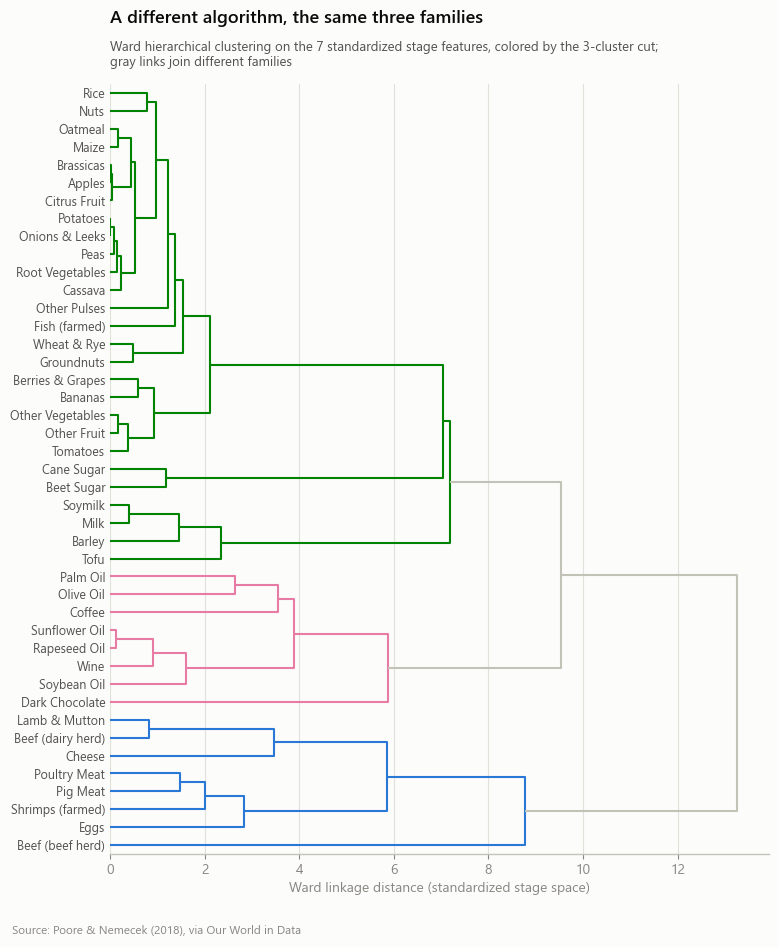

Ward 3-cluster cut sizes: {1: np.int64(8), 2: np.int64(8), 3: np.int64(27)}
  cluster 1 (livestock-like): ['Beef (beef herd)', 'Beef (dairy herd)', 'Cheese', 'Eggs', 'Lamb & Mutton', 'Pig Meat', 'Poultry Meat', 'Shrimps (farmed)']
  cluster 2 (tropical/oils-like): ['Coffee', 'Dark Chocolate', 'Olive Oil', 'Palm Oil', 'Rapeseed Oil', 'Soybean Oil', 'Sunflower Oil', 'Wine']
  cluster 3 (staples-like): ['Apples', 'Bananas', 'Barley', 'Beet Sugar', 'Berries & Grapes', 'Brassicas', 'Cane Sugar', 'Cassava', 'Citrus Fruit', 'Fish (farmed)', 'Groundnuts', 'Maize', 'Milk', 'Nuts', 'Oatmeal', 'Onions & Leeks', 'Other Fruit', 'Other Pulses', 'Other Vegetables', 'Peas', 'Potatoes', 'Rice', 'Root Vegetables', 'Soymilk', 'Tofu', 'Tomatoes', 'Wheat & Rye']


In [10]:
Z = linkage(X, method='ward')
cut3 = fcluster(Z, t=3, criterion='maxclust')

pos = {f: i for i, f in enumerate(df['Food product'])}
ward_color = {int(cut3[pos['Beef (beef herd)']]): BLUE, int(cut3[pos['Palm Oil']]): MAGENTA}
for c in set(cut3):
    ward_color.setdefault(int(c), GREEN)

n = len(df)
cluster_of = {i: int(cut3[i]) for i in range(n)}
link_cols = {}
for i, (a, b_, *_rest) in enumerate(Z):
    ca, cb = cluster_of.get(int(a)), cluster_of.get(int(b_))
    same = ca if (ca == cb and ca is not None) else None
    cluster_of[n + i] = same
    link_cols[n + i] = ward_color[same] if same is not None else BASE

fig, ax = plt.subplots(figsize=(8.5, 10))
dendrogram(Z, labels=df['Food product'].tolist(), orientation='right',
           link_color_func=lambda nid: link_cols.get(nid, BASE), ax=ax, leaf_font_size=9)
for lbl in ax.get_ymajorticklabels():
    lbl.set_color(INK2)
ax.tick_params(axis='y', length=0)
ax.set_xlabel('Ward linkage distance (standardized stage space)')
style_ax(ax, 'x', ('bottom',))
title_block(ax, 'A different algorithm, the same three families',
            'Ward hierarchical clustering on the 7 standardized stage features, colored by the '
            '3-cluster cut;\ngray links join different families', pad=44)
source_note(fig, y=0.03)
save_fig(fig, 'fig_slide06_dendrogram.png')
plt.show()

print('Ward 3-cluster cut sizes:', dict(pd.Series(cut3).value_counts().sort_index()))
for c in sorted(set(cut3)):
    name = {BLUE: 'livestock-like', MAGENTA: 'tropical/oils-like', GREEN: 'staples-like'}[ward_color[int(c)]]
    print(f'  cluster {c} ({name}):', sorted(df.loc[cut3 == c, 'Food product'])[:30])


**Check 2 result: Ward agrees.** Cutting the Ward tree at 3 clusters reproduces the same
three families with only edge moves: **Eggs joins the livestock cluster** (making it 8 foods,
still all-animal), **Dark Chocolate and Wine join the tropical/oils family** (8 foods), and
the two sugars fall back into the staples group (27 foods). The grouping is therefore not a
k-means artifact - the deepest split in the tree is livestock vs everything else, exactly the
k = 2 k-means solution.

### Model-selection metrics (feeds the slide-12 appendix)

| k | Silhouette - raw stages (main) | Cluster sizes | Silhouette - shares (check) | Cluster sizes |
|---:|---:|---|---:|---|
| 2 | **0.456** (optimum) | 36 \| 7 | **0.689** (degenerate optimum) | 42 \| 1 |
| 3 | 0.398 **(chosen)** | 28 \| 8 \| 7 | 0.264 | 26 \| 16 \| 1 |
| 4 | 0.410 | 26 \| 10 \| 6 \| 1 | 0.275 | 27 \| 12 \| 3 \| 1 |
| 5 | 0.436 | 24 \| 8 \| 6 \| 4 \| 1 | 0.299 | 22 \| 12 \| 5 \| 3 \| 1 |

Chosen model: **k = 3 on standardized raw stages** (clusters: Livestock & dairy 7, Low-impact
staples 28, Oil crops/sugar/coffee 8). Validation crosstab: livestock cluster = 7 animal /
0 plant; staples = 3 animal (Eggs, Fish, Milk) / 25 plant; oils = 0 animal / 8 plant.
Any k >= 4 (either pipeline) buys its silhouette by isolating a single outlier row -
Beef (beef herd) in the raw view, Nuts in the shares view.


## Limitations

- **n = 43 global averages.** Each row is one global mean; Poore & Nemecek's underlying data
  show enormous producer-level spread (the 10th-90th percentile range for beef spans tens of
  kg), so clusters describe *typical* products, not every farm. With 43 observations, single
  foods can visibly move results.
- **Outlier sensitivity.** Beef (beef herd) is extreme enough to become its own cluster at
  k >= 4, and Nuts' near-zero net total degenerates the shares pipeline at k = 2. We chose k
  by silhouette *plus* interpretability and documented both optima rather than hiding them.
- **K-means assumptions.** K-means prefers spherical, similarly sized clusters in the scaled
  space and hard-assigns borderline foods (Dark Chocolate flips family between k = 3, k = 4
  and Ward). The Ward check mitigates but does not eliminate this.
- **Standardization choice.** Silhouette values depend on the feature scaling decision;
  we report scores within each pipeline, not across pipelines.
- **Stage taxonomy.** The 7 stages are already aggregates (e.g. "Farm" bundles methane,
  fertilizer, machinery); transport here is the supply-chain average and excludes rare
  air-freighted produce, a known exception to the "transport is small" rule.
- **Vintage.** The source synthesizes studies up to ~2016 (published 2018); absolute values
  will have shifted, though the orders of magnitude that drive the clusters are stable.


## Sources

- Poore, J., & Nemecek, T. (2018). Reducing food's environmental impacts through producers
  and consumers. *Science*, 360(6392), 987-992. Data as distributed by Our World in Data
  (`data/Food_Product_Emissions.csv`).
- Emissions basis: "Total from Land to Retail" (land-to-retail total) throughout; the
  "Total Global Average GHG Emissions per kg" column (adds post-retail losses) is quoted only
  as a footnoted alternative basis.
- Tooling: Python 3.12, pandas 3.0, scikit-learn 1.8 (StandardScaler, KMeans, PCA,
  silhouette), scipy 1.17 (Ward linkage), matplotlib 3.10. All stochastic steps use
  `random_state=42`.
